In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight

In [2]:
T = 20
dt = 0.5e-3
bat_flight = generate_bat_flight(
    T=T,
    dt=dt,
    speed_correlation_time=5,
    initial_heading=[1,0,-1]
)

100%|██████████| 39999/39999 [00:02<00:00, 17510.50it/s]


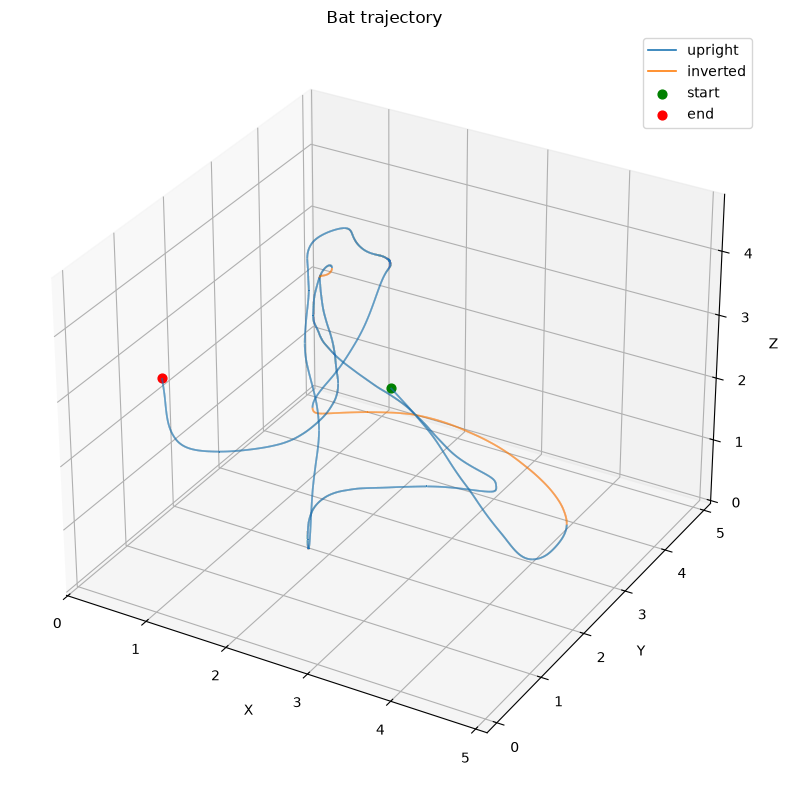

In [ ]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

inverting = bat_flight["inverted"]

pos = bat_flight["pos"]
inverted = pos[inverting]
upright = pos[~inverting]



segments = np.stack([pos[:-1], pos[1:]], axis=1)
colors = np.where(inverting[:-1], "tab:orange", "tab:blue")

ax.add_collection3d(
    Line3DCollection(segments, colors=colors, linewidths=1.2)
)
# Add legend entries for the trajectory color states
ax.plot([], [], color="tab:blue", lw=1.2, label="upright")
ax.plot([], [], color="tab:orange", lw=1.2, label="inverted")
ax.scatter(pos[0, 0], pos[0, 1], pos[0, 2], color="green", s=40, label="start")
ax.scatter(pos[-1, 0], pos[-1, 1], pos[-1, 2], color="red", s=40, label="end")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Bat trajectory")
ax.legend()
plt.tight_layout()
plt.show()

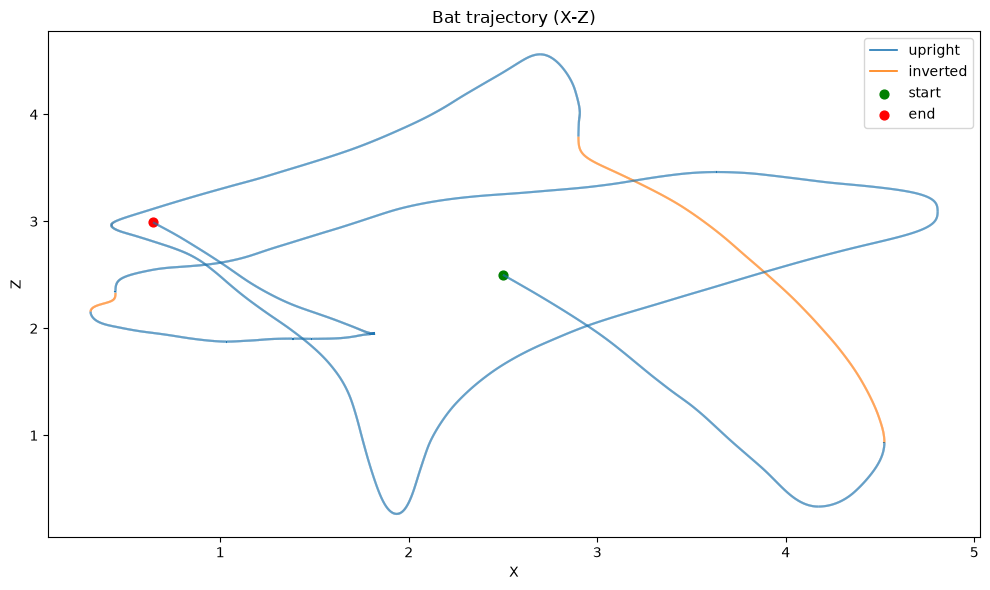

In [7]:
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

fig2, ax2 = plt.subplots(figsize=(10, 6))

segments_xz = np.stack([pos[:-1, [0, 2]], pos[1:, [0, 2]]], axis=1)
colors = np.where(inverting[:-1], "tab:orange", "tab:blue")


ax2.add_collection(LineCollection(segments_xz,colors=colors))
ax2.plot([], [], color="tab:blue", lw=1.2, label="upright")
ax2.plot([], [], color="tab:orange", lw=1.2, label="inverted")


ax2.scatter(pos[0, 0], pos[0, 2], color="green", s=40, label="start")
ax2.scatter(pos[-1, 0], pos[-1, 2], color="red", s=40, label="end")

ax2.set_xlabel("X")
ax2.set_ylabel("Z")
ax2.set_title("Bat trajectory (X-Z)")
ax2.legend(loc="best")
plt.tight_layout()
plt.show()

In [5]:
(bat_flight["dir_torus"] / np.pi).max(axis = 0 )

array([1.99998194, 1.99964525])

In [6]:
def compute_spherical_coordinates(heading):
    """
    Convert 3D Cartesian heading vector to spherical coordinates (azimuth, pitch).

    Args:
        heading: 3D heading vector or array of heading vectors.

    Returns:
        Array of (azimuth, pitch) angles in radians.
    """
    heading = np.asarray(heading, dtype=float)
    heading_norm = np.linalg.norm(heading, axis=-1, keepdims=True)
    heading = heading / np.clip(heading_norm, 1e-12, None)

    azimuth = np.arctan2(heading[..., 1], heading[..., 0])
    pitch = np.arcsin(np.clip(heading[..., 2], -1.0, 1.0))

    return np.stack((azimuth, pitch), axis=-1)

compute_spherical_coordinates([0,0,-1])/np.pi

array([ 0. , -0.5])